In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
path = r'E:\E-commerce Analysis\Data\processed\fato_vendas_tratada.csv'
df = pd.read_csv(path)

In [4]:
df.head()

,order_id,order_purchase_timestamp,order_status,customer_id,customer_state,product_id,product_category_name,seller_id,price,freight_value,total_payment
0,016befe103ce7c9e5b1b7ef359777eea,2017-09-03 10:11:52,delivered,15f3f60c0575a9f2a7d5434f7b8a7692,SP,6c321ed0f47858a8650f4104771224b5,relogios_presentes,6560211a19b47992c3666cc44a7e94c0,49.00,11.85,60.85
1,035c01a45e289b155db4e47cf39b29d3,2018-08-06 22:01:08,delivered,d68f9c633f9ab44265b54f3792fcbe71,SP,656e0eca68dcecf6a31b8ececfabe3e8,informatica_acessorios,5f67c6082caacb26e431a7b17940cece,79.90,13.90,93.80
2,b7e339d3c4aefa73f6e86875b78250f3,2017-12-17 22:36:30,delivered,454b89aa74cc3a41ac6a964e7f6c9e67,SP,2029248294c186017ecfc48cecd47bbd,ferramentas_jardim,d50d79cb34e38265a8649c383dcffd48,129.99,17.62,147.61
3,8e0aba4e9cd80e71b2cec14e22df868b,2017-11-15 12:08:23,delivered,5a23a92261328e087c062a7c265b7862,RN,a1766f2d27b4e90a0d78d8e115295399,perfumaria,17e34d8224d27a541263c4c64b11a56b,102.48,34.52,137.00
4,9564498225916371a8670c3b0253ea81,2017-05-06 08:54:37,delivered,403d065ed4e3882fb44ac77fe8297132,BA,a99b67c7e525bb5ca667e1aa284c28e2,esporte_lazer,adcf50477d6a1f5d91bb9d54c4903cb5,17.55,26.78,177.32


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  113425 non-null  str    
 1   order_purchase_timestamp  113425 non-null  str    
 2   order_status              113425 non-null  str    
 3   customer_id               113425 non-null  str    
 4   customer_state            113425 non-null  str    
 5   product_id                112650 non-null  str    
 6   product_category_name     113425 non-null  str    
 7   seller_id                 112650 non-null  str    
 8   price                     113425 non-null  float64
 9   freight_value             113425 non-null  float64
 10  total_payment             113425 non-null  float64
dtypes: float64(3), str(8)
memory usage: 9.5 MB


In [6]:
pd.options.display.float_format = '{:,.2f}'.format

In [7]:
df['order_purchase_timestamp'] = df['order_purchase_timestamp'].astype('datetime64[ns]')
df['order_status'] = df['order_status'].astype('category')
df['customer_state'] = df['customer_state'].astype('category')
df['product_category_name'] = df['product_category_name'].astype('category')

df['price'] = df['price'].astype('float32')
df['freight_value'] = df['freight_value'].astype('float32')
df['total_payment'] = df['total_payment'].astype('float32')

In [8]:
#Faturamento Total
faturamento_total = df['total_payment'].sum()
print(f"{faturamento_total:,.2f}")

20,470,728.00


In [9]:
#Número de Pedidos
numero_pedidos = df['order_id'].count()
print(numero_pedidos)

113425


In [10]:
#Ticket Médio
ticket_medio = faturamento_total / numero_pedidos
print(f"{ticket_medio:,.2f}")

180.48


In [11]:
#Pedidos por Mês
df['order_id'].groupby(df['order_purchase_timestamp'].dt.to_period('M')).count()

order_purchase_timestamp
2016-09       7
2016-10     379
2016-12       1
2017-01     966
2017-02    1998
2017-03    3041
2017-04    2697
2017-05    4176
2017-06    3611
2017-07    4576
2017-08    4948
2017-09    4873
2017-10    5385
2017-11    8758
2017-12    6357
2018-01    8257
2018-02    7706
2018-03    8240
2018-04    7980
2018-05    7945
2018-06    7085
2018-07    7111
2018-08    7308
2018-09      16
2018-10       4
Freq: M, Name: order_id, dtype: int64

In [ ]:
#Faturamento por Estado
receita_por_estado = df.groupby('customer_state')['total_payment'].sum().sort_values(ascending=False)
print(receita_por_estado)

customer_state
SP   7,673,188.50
RJ   2,783,724.25
MG   2,341,861.50
RS   1,152,019.12
PR   1,074,614.25
BA     802,416.75
SC     799,135.94
GO     516,182.50
DF     434,512.56
ES     406,946.25
PE     378,887.47
CE     347,678.38
PA     262,433.12
MT     257,447.66
MA     199,913.56
PB     181,546.00
MS     165,861.45
PI     137,077.67
RN     117,074.43
AL     111,993.78
SE      90,651.44
TO      72,412.08
RO      69,184.48
AM      34,873.79
AC      24,984.86
AP      21,642.70
RR      12,462.21
Name: total_payment, dtype: float32


In [13]:
#Quantidade Vendida por Estado
quantidade_vendida_estado = df.groupby('customer_state')['order_id'].count().sort_values(ascending=False)
print(quantidade_vendida_estado)

customer_state
SP    47820
RJ    14669
MG    13220
RS     6269
PR     5787
SC     4201
BA     3821
DF     2421
GO     2346
ES     2264
PE     1810
CE     1487
PA     1085
MT     1059
MA      831
MS      825
PB      606
PI      544
RN      532
AL      446
SE      390
TO      316
RO      284
AM      166
AC       92
AP       82
RR       52
Name: order_id, dtype: int64


In [20]:
#Ticket Médio por categoria de produto
ticket_medio_categoria = df.groupby('product_category_name')['total_payment'].mean().sort_values(ascending=False)
ticket_medio_categoria

product_category_name
pcs                           1,374.98
telefonia_fixa                  784.13
portateis_casa_forno_e_cafe     674.07
agro_industria_e_comercio       560.05
eletrodomesticos_2              523.38
                                ...   
livros_tecnicos                  93.32
alimentos                        91.04
cds_dvds_musicais                85.67
flores                           67.06
casa_conforto_2                  57.02
Name: total_payment, Length: 74, dtype: float32

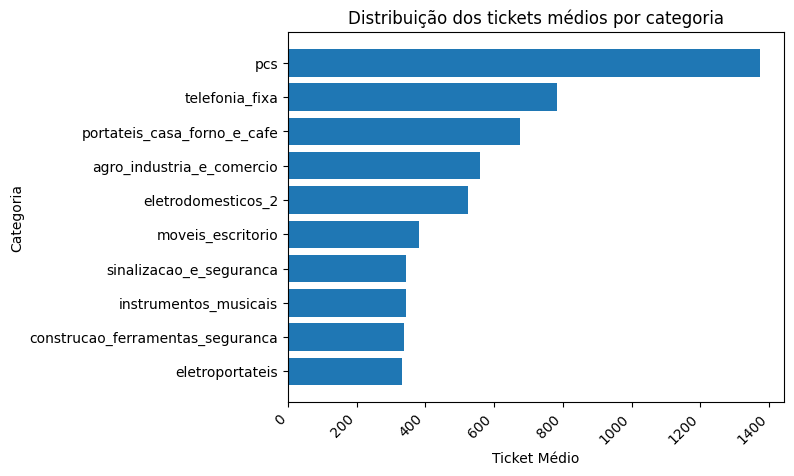

In [ ]:
#Distribuição de Ticket Médio
top_10_categorias = ticket_medio_categoria.sort_values(ascending=False).head(10)

plt.barh(top_10_categorias.index, top_10_categorias.values)

plt.title("Distribuição dos tickets médios por categoria")
plt.xlabel("Ticket Médio")
plt.ylabel("Categoria")

plt.xticks(rotation=45, ha='right')

plt.gca().invert_yaxis()

plt.show()
